## A PROJECT BY TATENDA USAI

## This project involves analyzing the data to get a fair idea about the demand of different restaurants which will help the company to enhance business and customer experience.

### Exploratory Data Analysis | Data Visualization | Statistics

# Project Foundations for Data Science - Python and Statistics: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For python to display graphs inline
# %matplotlib inline

### Understanding the structure of the data

In [2]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# read the data
df = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE AND MACHINE LEARNING/Foundations of Data Science/Project/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data?

In [4]:
# Checking the data shape
print("We have", df.shape[0], "rows and", df.shape[1], "columns.")

We have 1898 rows and 9 columns.


#### Observations:
* There are a total of 1898 rows representing orders that have been placed by customers using the application.
* The orders are described by 9 columns, each with a unique data point as observed in the data's first 5 rows above.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used)

In [5]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
* There are 5 numerical columns and 4 object type columns
* On the numerical columns there is 1 column with decimal values and 4 columns with whole numbers
* restaurant_name, cuisine_type and day_of_the_week are string data types
* rating is supposed to be a numerical type with integers, but instead is displayed as an object type. This may be due to missing values


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [6]:
# checking the unique values we have in the rating column
df["rating"].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [7]:
# checking all the type counts we have in the rating column
df["rating"].apply(type).value_counts()

,count
rating,
<class 'str'>,1898


In [8]:
# replacing values that are not given with nan
df["rating"] = df["rating"].replace(["Not given"], np.nan)

# converting rating column from type object to type float
df["rating"] = df["rating"].astype(float)

In [9]:
# checking the new data type of the rating column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


In [10]:
# checking for missing values
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


In [11]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
# Percentange of missing data from the rating column
(df["rating"].isnull().sum() / (df["rating"].count() + df["rating"].isnull().sum())) * 100

np.float64(38.77766069546891)

CHECK HOW LINE IMPUTING IS AFFECTING DATA

In [13]:
#Imputing missing values for rating coulumn using the mean
#df["rating"] = df["rating"].fillna(value = int(df["rating"].mean()))

In [14]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24


#### Observations:
* The values from the rating column were all numerical integers except 736 values that were recorded as "Not given"
* After converting the "Not given" value to nan (not a number) the data in rating column could now be converted to a float type which is better for doing data analysis
* The only missing values were from the rating column
* The missing data translates to 38.8 percent of the total values in the rating column
* The mean of our rating column is 4 rounded to the nearest integer, with a standard deviation of 0.741. This means that the data is well balanced and the mean can be used to impute missing values
* There are no duplicate values in the data set

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [15]:
# restricting float values to 3 decimal places
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Checking statistical summary of data
df.describe()
#df.describe().T

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1898.000,1898.000,1898.000,1162.000,1898.000,1898.000
mean,1477495.500,171168.478,16.499,4.344,27.372,24.162
std,548.050,113698.140,7.484,0.741,4.632,4.973
min,1476547.000,1311.000,4.470,3.000,20.000,15.000
25%,1477021.250,77787.750,12.080,4.000,23.000,20.000
50%,1477495.500,128600.000,14.140,5.000,27.000,25.000
75%,1477969.750,270525.000,22.297,5.000,31.000,28.000
max,1478444.000,405334.000,35.410,5.000,35.000,33.000


In [16]:
# Converting decimal to minutes for the average time it takes to prepare food once an order is placed
print(27, "minutes and", int(0.372 * 60), "seconds")

27 minutes and 22 seconds


#### Observations:
* It takes a minimun of 20 minutes to prepare food
* It takes an average of 27 minutes and 22 seconds to prepare food
* It takes a maximum of 35 minutes to prepare food


### **Question 5:** How many orders are not rated?

In [17]:
# Number of unrated orders
print(df["rating"].isnull().sum(), "orders are not rated")

736 orders are not rated


#### Observations:
* There are 736 orders that were not rated
* This may be due to customers forgetting or not being interested in rating the service


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration)

In [18]:
# to see all category names

df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.750,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5.000,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3.000,25,15
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4.000,25,24


### **Order ID**

In [19]:
# checking for duplicate order ids
print("There are", (df["order_id"].duplicated().sum()), "duplicated order ids.")

There are 0 duplicated order ids.


* This shows us that all orders made through the application are unique individual transactions.
* Given that all values for this variable have unique values that are in a randomised order there is no need for graphical illustraction

### **Customer ID**

In [20]:
# checking for duplicate customer ids
print("There are", (df["customer_id"].duplicated().sum()), "duplicated customer ids.")

There are 698 duplicated customer ids.


* Having duplicate customer IDs is an indicator that the application has repeat customers
* The volume of orders made by customers can be better illustrated by a graph

In [21]:
# While loop comprehending customer_id data to group the customers by frequency at which they made orders on the application
customer_volume_list = {}
customer_frequency = 1

while customer_frequency <= 13:
 customer_volume = (df["customer_id"].value_counts() == customer_frequency).sum()
 customer_volume_list.update({customer_frequency : customer_volume})
 customer_frequency += 1

In [22]:
print(customer_volume_list)

{1: np.int64(784), 2: np.int64(267), 3: np.int64(83), 4: np.int64(33), 5: np.int64(19), 6: np.int64(6), 7: np.int64(4), 8: np.int64(1), 9: np.int64(1), 10: np.int64(1), 11: np.int64(0), 12: np.int64(0), 13: np.int64(1)}


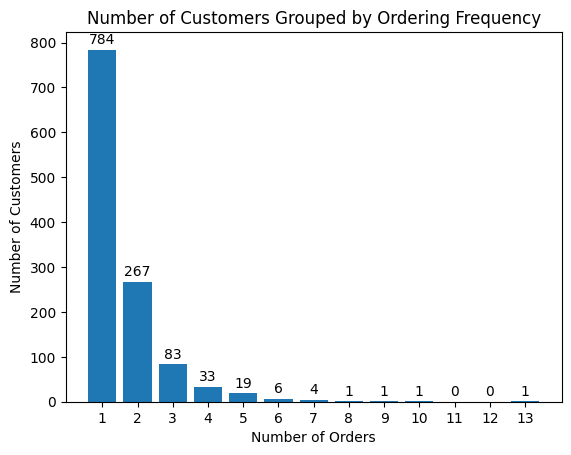

In [23]:
 # declaring variables
data = customer_volume_list
frequency = list(data.keys())
volume = list(data.values())

 # setting axis values for plotting the graph
customer_id_barplot = plt.bar(range(len(data)), volume, tick_label=frequency)

 # adding value labels on top of each bar
plt.bar_label(customer_id_barplot, labels = volume, label_type = "edge", padding = 2,)

 # giving title to the plot
plt.title("Number of Customers Grouped by Ordering Frequency")

 # giving X and Y labels
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

* The largest number of customers(784) only made one order
* As the number of orders gets larger the number of customers reduces
* Starting from 8 orders up to 13 (excluding 11 and 12 orders) only 1 customer is recorded in each column

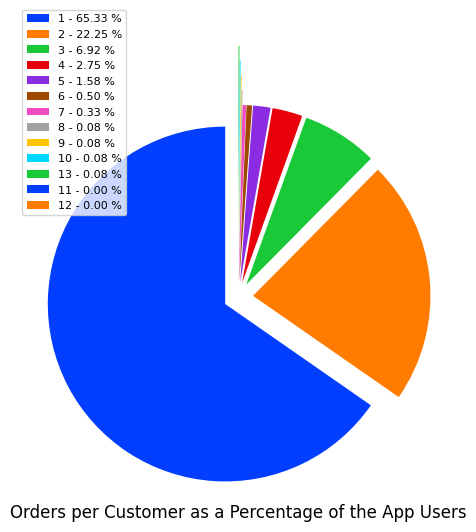

In [24]:
# declaring variabless
volume2 = np.array(volume)
frequency2 = frequency

# Seaborn color palette to plot pie chart
colors = sns.color_palette('bright')

# percentages
percentages = 100.*volume2/volume2.sum()

# scale of chart explosion
explode = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.3, 0.4, 0.4, 0.4, 0.5 ]

# create pie chart using matplotlib
patches, texts = plt.pie(volume2, colors=colors, startangle=90, radius=1.2, explode=explode,)

# creating the legend
labels = ['{0} - {1:1.2f} %'.format(i,j) for i,j in zip(frequency2, percentages)]

sort_legend = True
if sort_legend:
    patches, labels, dummy =  zip(*sorted(zip(patches, labels, volume2),
                                          key=lambda x: x[2],
                                          reverse=True))

plt.legend(patches, labels, loc='center left', bbox_to_anchor=(-0.1, 1.),
           fontsize=8)

 # giving title to the plot
plt.title("Orders per Customer as a Percentage of the App Users", y= -0.12)


plt.savefig('piechart.png', bbox_inches='tight')

* Over 80 percent of customers made only 1 or 2 orders
* Almost two-thirds of customers only made 1 order

### **Restaurant Name**

In [25]:
# checking for duplicated restaurant names

df["restaurant_name"].duplicated().value_counts()

,count
restaurant_name,
True,1720
False,178


* There are 1720 duplicated restaurant names and 178 that have a single entry, this means that some restaurants had more than 1 order made to them through the application

In [26]:
# listing restaurants and their order count
df["restaurant_name"].groupby(df['restaurant_name']).count().reset_index(
  name='sum').sort_values(['sum'], ascending=False)

,restaurant_name,sum
136,Shake Shack,219
153,The Meatball Shop,132
21,Blue Ribbon Sushi,119
20,Blue Ribbon Fried Chicken,96
109,Parm,68
...,...,...
152,The MasalaWala,1
148,Taro Sushi,1
168,Woorijip,1
164,Wa Jeal,1


* There are 178 restaurants that have gotten orders through the application

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


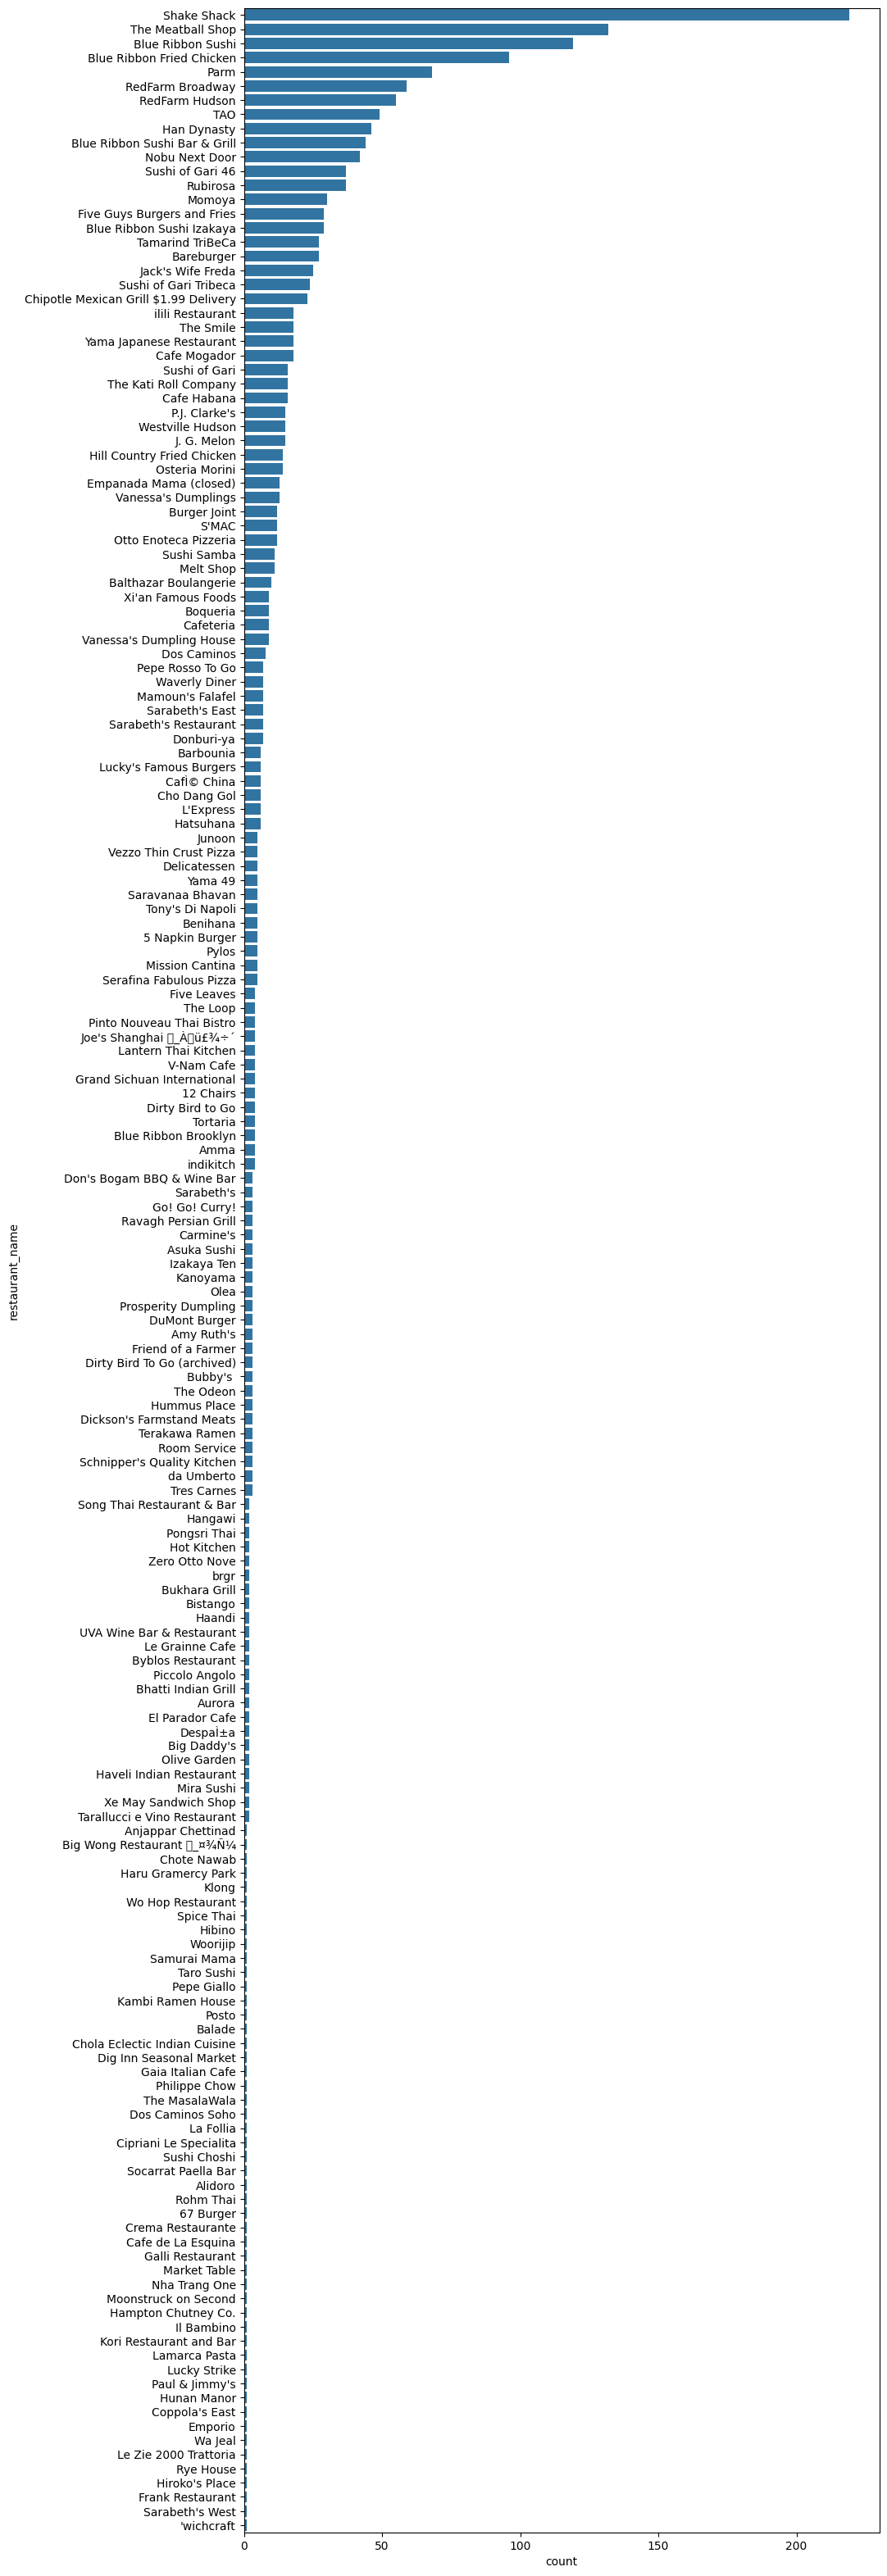

In [27]:
# ploting bar graph for restaurants against order count
plt.figure(figsize= (10,40))
sns.countplot(data=df,y='restaurant_name', order=df["restaurant_name"].value_counts().index)
plt.show()

* The cumulative frequency bar graph shows the restaurants' order count from highest to lowest
* Shake Shack is by far the restaurant with most orders with 219 orders
* The number of restaurants increase as the number of orders reduce

### **Cuisine Type**

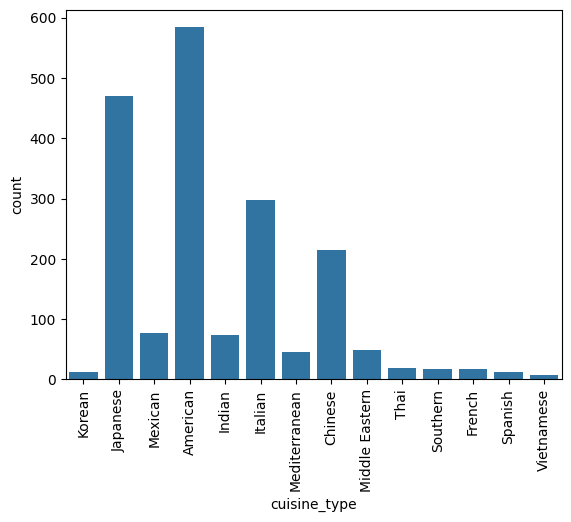

In [28]:
# plotting a count plot of cuisine type against order count

sns.countplot(data=df,x='cuisine_type')
plt.xticks(rotation=90)
plt.show()

* American cuisine is the most popular among customers followed by Japanese cuisine
* Vietnamese is the least popular cuisine
* Majority of orders are made up of 4 cuisine types namely American, Japanese, Mediterranean and Chinese

### **Cost of the Order**

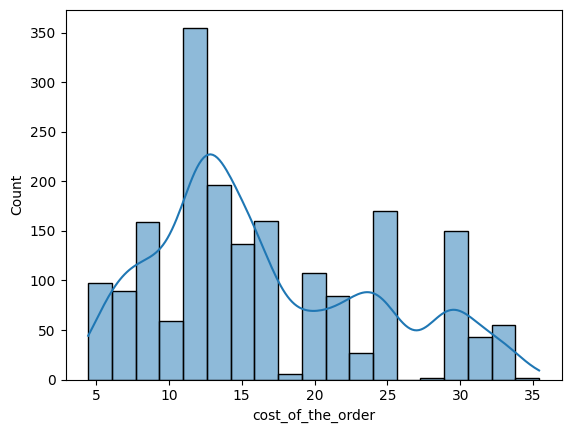

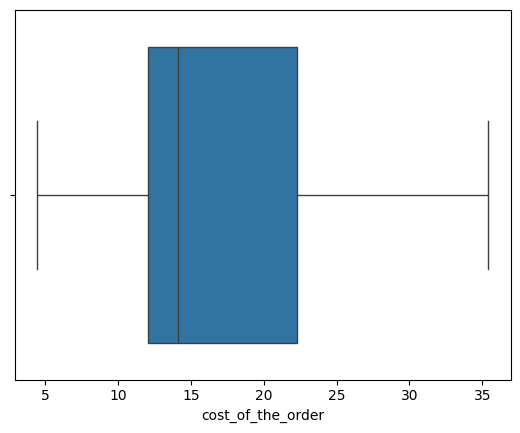

In [29]:
# plotting a histogram and a boxplot to compare data and central tendencies

sns.histplot(data=df,x='cost_of_the_order', kde= True)
plt.show()
sns.boxplot(data=df,x='cost_of_the_order')
plt.show()

In [30]:
# cost of order summary statistics
round(df['cost_of_the_order'].describe(), 2)

,cost_of_the_order
count,1898.000
mean,16.500
std,7.480
min,4.470
25%,12.080
50%,14.140
75%,22.300
max,35.410


* The data for cost of orders is right skewed
50 percent of customers order food costing between 12 to 22 dollars as oulined by Q1 and Q3
* The average meal cost is 16 dollars and 50 cents
* There are no outliers in this data
The most expensive orders range up to 35 dollars and 41 cents and the cheapest go as low as 4 dollors and 4 cents


### **Day of the Week**

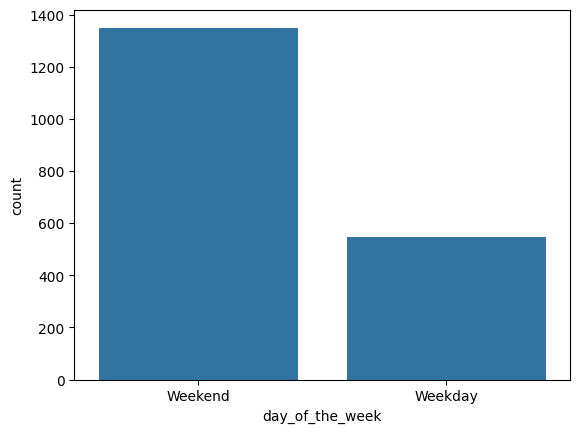

In [31]:
# plotting a count plot for day of the week

sns.countplot(data=df,x='day_of_the_week')
plt.show()

* Weekends are the busiest days for the application, the orders are twice as many as on weekdays

### **Rating**

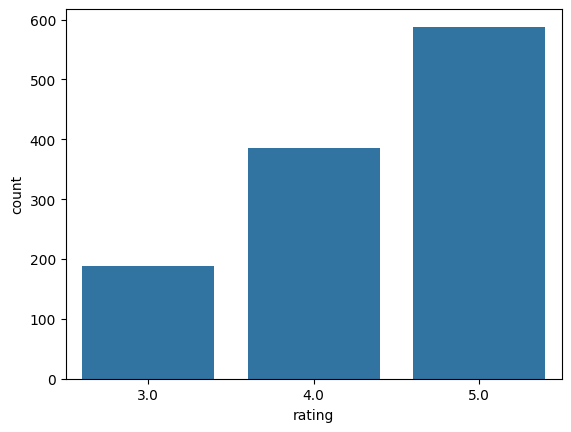

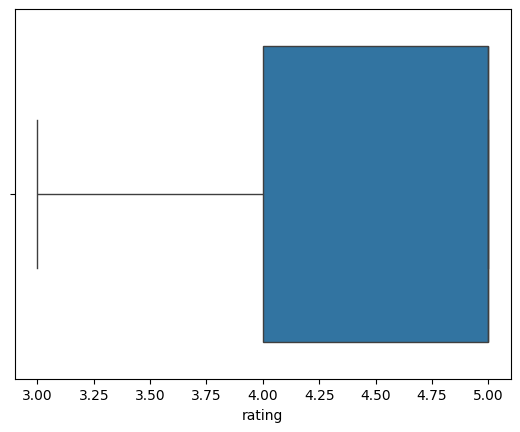

In [32]:
# plotting a count plot for rating and a box plot to compare data

sns.countplot(data=df,x='rating')
plt.show()
sns.boxplot(data=df,x='rating')
plt.show()

* The data for rating is left skewed
* Most customers have had a good experience using the application, hence the highest volume of ratings are 4 and 5 stars
* The average rating accross all restaurants on the application is 4 stars, this is also the median

### **Food Preparation Time**

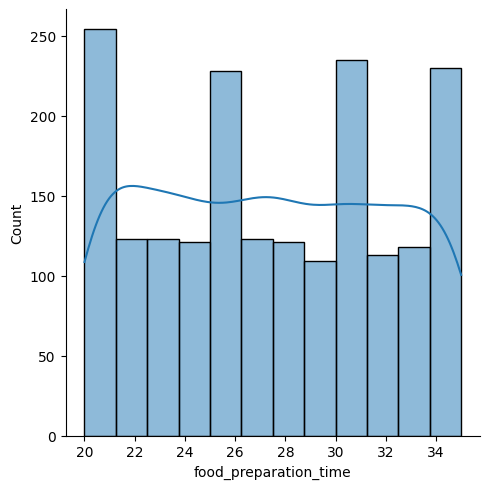

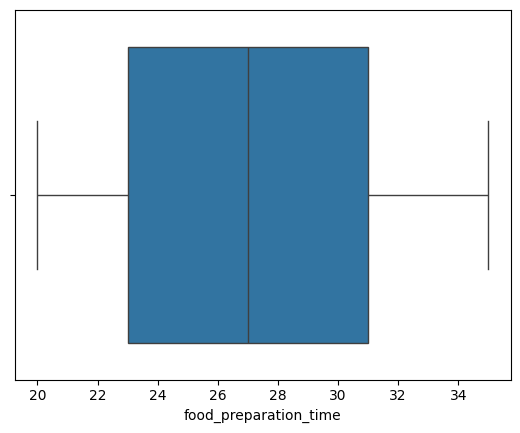

In [33]:
# Food preperation time histogram with kde and boxplot

sns.displot(data=df,x=df['food_preparation_time'],kde= True)
plt.show()
sns.boxplot(data=df,x=df['food_preparation_time'])
plt.show()

* Food preperation time foolows a uniform distribution as shown by the kde
* The box plot shows that the mean is at the center of the data showing even more that it is evenly distributed

### **Delivery Time**

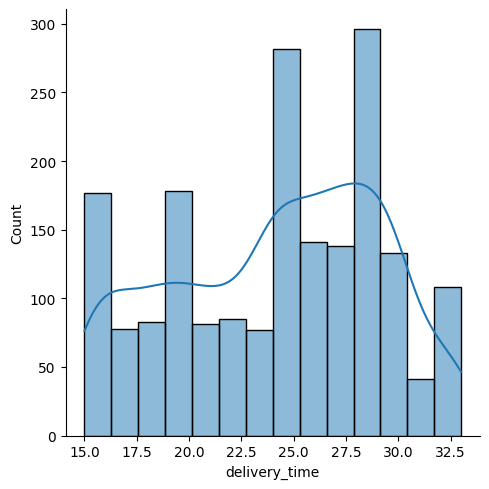

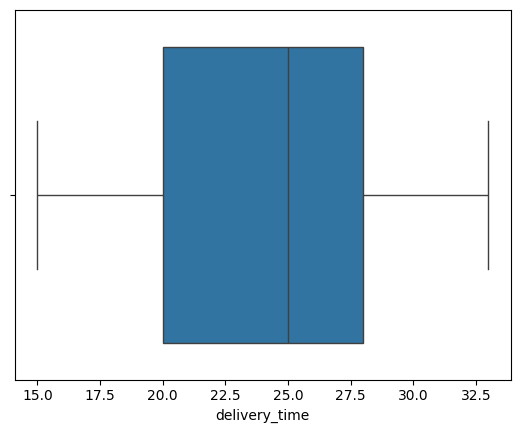

In [34]:
# Delivery time histogram with kde and boxplot

sns.displot(data=df,x=df['delivery_time'],kde= True)
plt.show()
sns.boxplot(data=df,x=df['delivery_time'])
plt.show()

* The data for delivery time is slightly left skewed
* This means that most orders take a bit longer to get deliveed than some that have a shorter delivery time
* There are no outliers in this data, most deliveries are done within 15 to 32 minutes

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

In [35]:
# grouping and arranging restaurants by order count

top_restaurants = df["restaurant_name"].groupby(df['restaurant_name']).count().reset_index(
  name='Count').sort_values(['Count'], ascending=False)

# showing only the top 5 restaurants

top_5_restaurants = top_restaurants.head()

top_5_restaurants

,restaurant_name,Count
136,Shake Shack,219
153,The Meatball Shop,132
21,Blue Ribbon Sushi,119
20,Blue Ribbon Fried Chicken,96
109,Parm,68


#### Observations:

* Shake Shack, has by for the most orders more than 3 times that of the 5th restaurant on the list (Parm)
* The top three restaurants have over 100 orders

### **Question 8**: Which is the most popular cuisine on weekends?

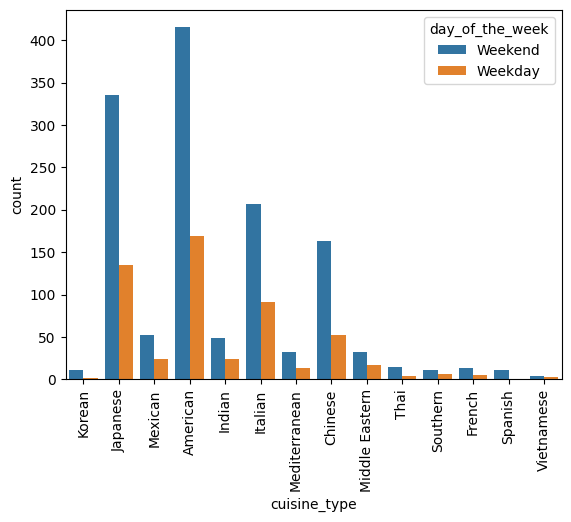

In [36]:
# showing cusine popularity by day of the week

sns.countplot(data=df,x='cuisine_type', hue = "day_of_the_week")
plt.xticks(rotation=90)
plt.show()

#### Observations:
* American is the most popular cuisine on weekends
* Japanese is a close second
* Majority of orders are made on the weekend for the top 4 restaurants as shown by the graph

### **Question 9**: What percentage of the orders cost more than 20 dollars?

In [37]:
# locating rows with over 20 dollar orders

rows_with_orders_over_20_dollar = df.loc[df['cost_of_the_order'] > 20]

In [38]:
# calculating the percentage of orders over 20 dollars

orders_over_20_dollar = round((rows_with_orders_over_20_dollar['cost_of_the_order'].value_counts().sum() / df['cost_of_the_order'].value_counts().sum())* 100, 2)

print("The percentage of orders that costs above 20 dollars is", orders_over_20_dollar,"%")

The percentage of orders that costs above 20 dollars is 29.24 %


#### Observations:

* 29.24 percent of orders cost more than 20 dollars
* About 70% of orders cost 20 dollars or less
* This shows that most customers are looking for cheaper meals


### **Question 10**: What is the mean order delivery time?

In [39]:
#calculating the mean oder delivery time

mean_delivery_time = round(df["delivery_time"].mean(), 3)

mean_delivery_time

np.float64(24.162)

In [40]:
# converting to mean time

print("The average order delivery time is", int(mean_delivery_time), "minutes and", int(0.162*60), "seconds.")

The average order delivery time is 24 minutes and 9 seconds.


#### Observations:

* On average orders take 24 minutes and 9 seconds to deliver

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed

In [41]:
# grouping data by customer id and order count, descending

top_customers = df["customer_id"].groupby(df['customer_id']).count().reset_index(
  name='number of orders').sort_values(['number of orders'], ascending=False)

# showing only the top 3 customers

top_3_customers = top_customers.head(3)

top_3_customers


,customer_id,number of orders
116,52832,13
84,47440,10
333,83287,9


#### Observations:

* The top customers has 13 orders
* The second top customer has 10 orders
* The last top customer has 9 orders
* There are no customers who made 11 or 12 orders


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)

gauge demand of certain restaurants to increase customer satisfaction

### **Heat Map of Numeric Variables**

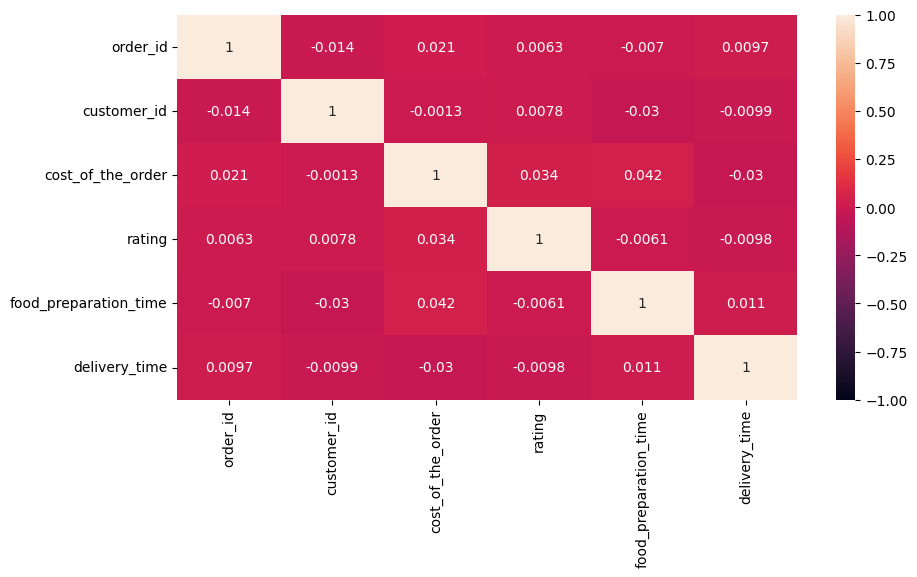

In [43]:
import numpy as np
# plotting heatmap

plt.figure(figsize=(10,5))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),annot=True,vmin=-1,vmax=1,)
plt.show()

* There is a very weak correlation between all numeric variables
* The biggest correlation is between food preparation time and cost of order, but there is not enough of a correlation to conclude that it is important
* There also a slight positive correlation between rating and cost of order, again it is quite weak and inconclusive
* The weak correlations of the data is indicating that there may be some other factors that influence customer behavior and satisfaction


### **Rating x Cost of Order**

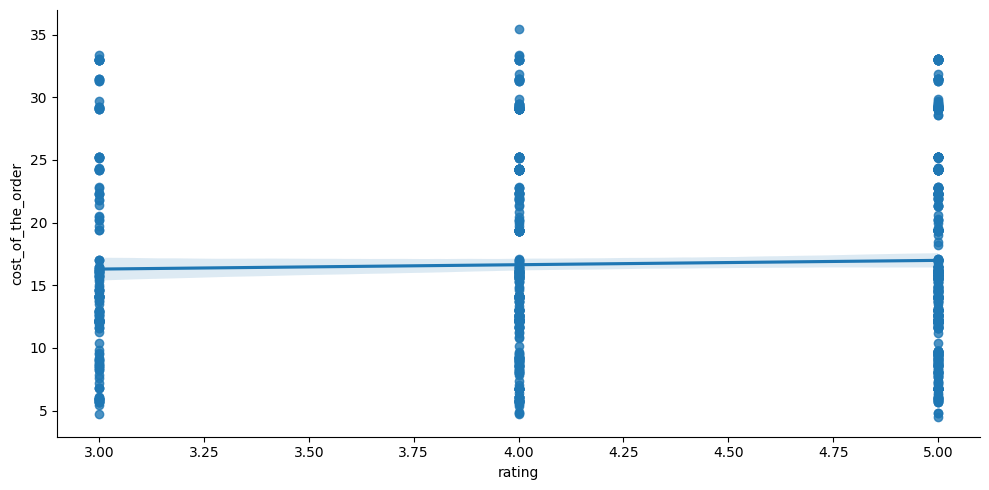

In [44]:
# ploting rating agaist cost of order and puting a line of best fit

sns.lmplot(data=df,x='rating',y='cost_of_the_order',height=5,aspect=2)
plt.show()

* There is a slight weak positive correlation between cost of oder and rating
* This may be hinting that the food that costs more is of higher quality or better taste
* More data is needed to prove this

### **Rating x Food Preparation Time**

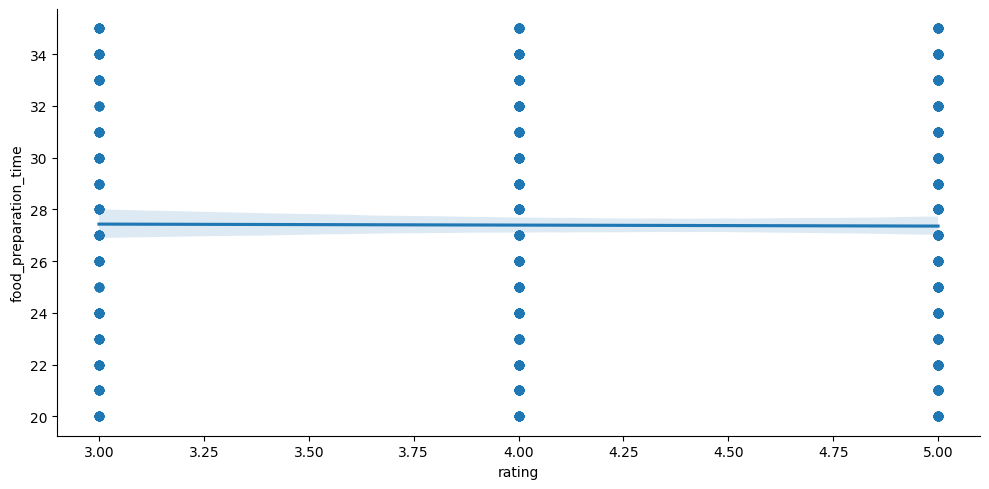

In [45]:
# plot for rating against food preparation time

sns.lmplot(data=df,x='rating',y='food_preparation_time',height=5,aspect=2)
plt.show()

* Food preparation time and rating have a largely uniform relationship based on the graph, this is because there is because food preparation time is largely uniform

### **Rating x Delivery Time**

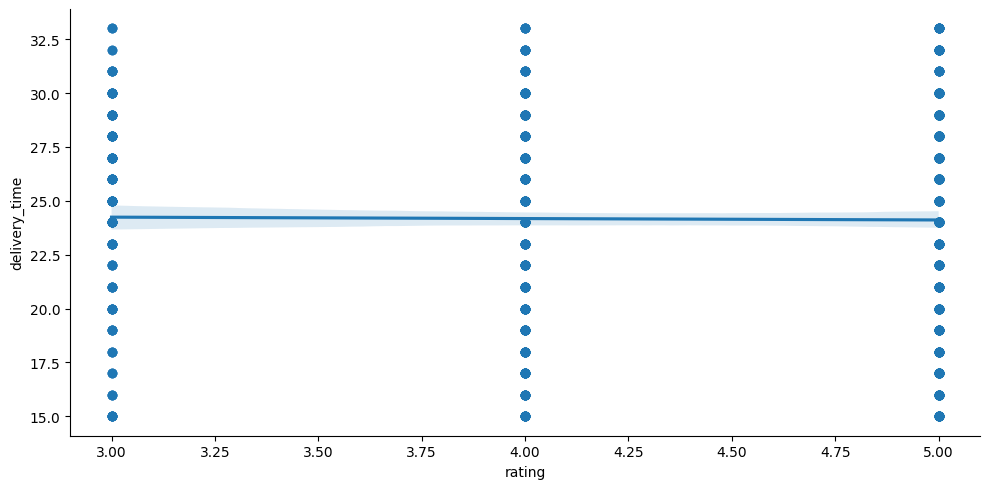

In [46]:
# delivery time x rating graph

sns.lmplot(data=df,x='rating',y='delivery_time',height=5,aspect=2)
plt.show()

* Higher delivery times have a lowe rating slightly on the average
* The correlation is weak and the data is almost uniform

### **Pair Plot**

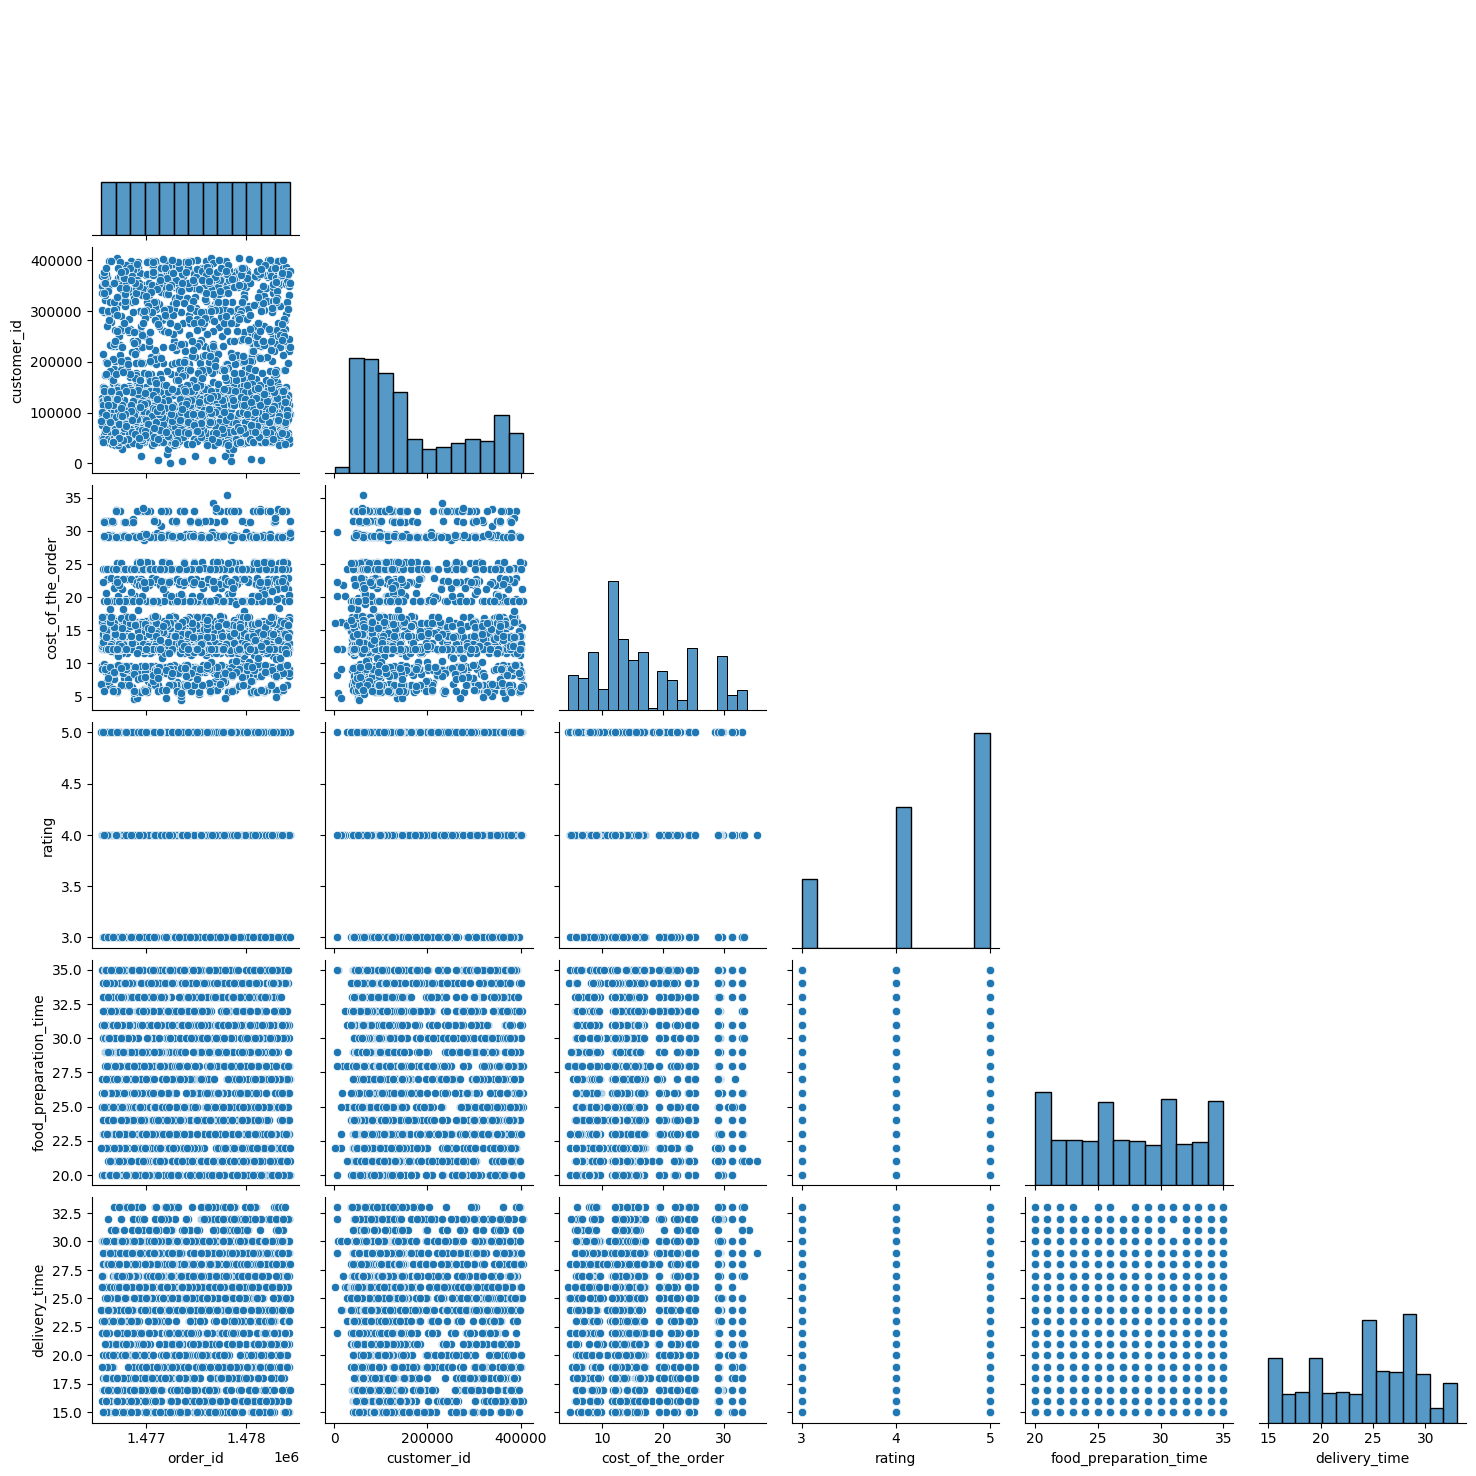

In [47]:
# pair plot

sns.pairplot(data=df, corner = True)

* This further shows that the numeric categories are very weakly related

### **Cuisine Type x Rating**

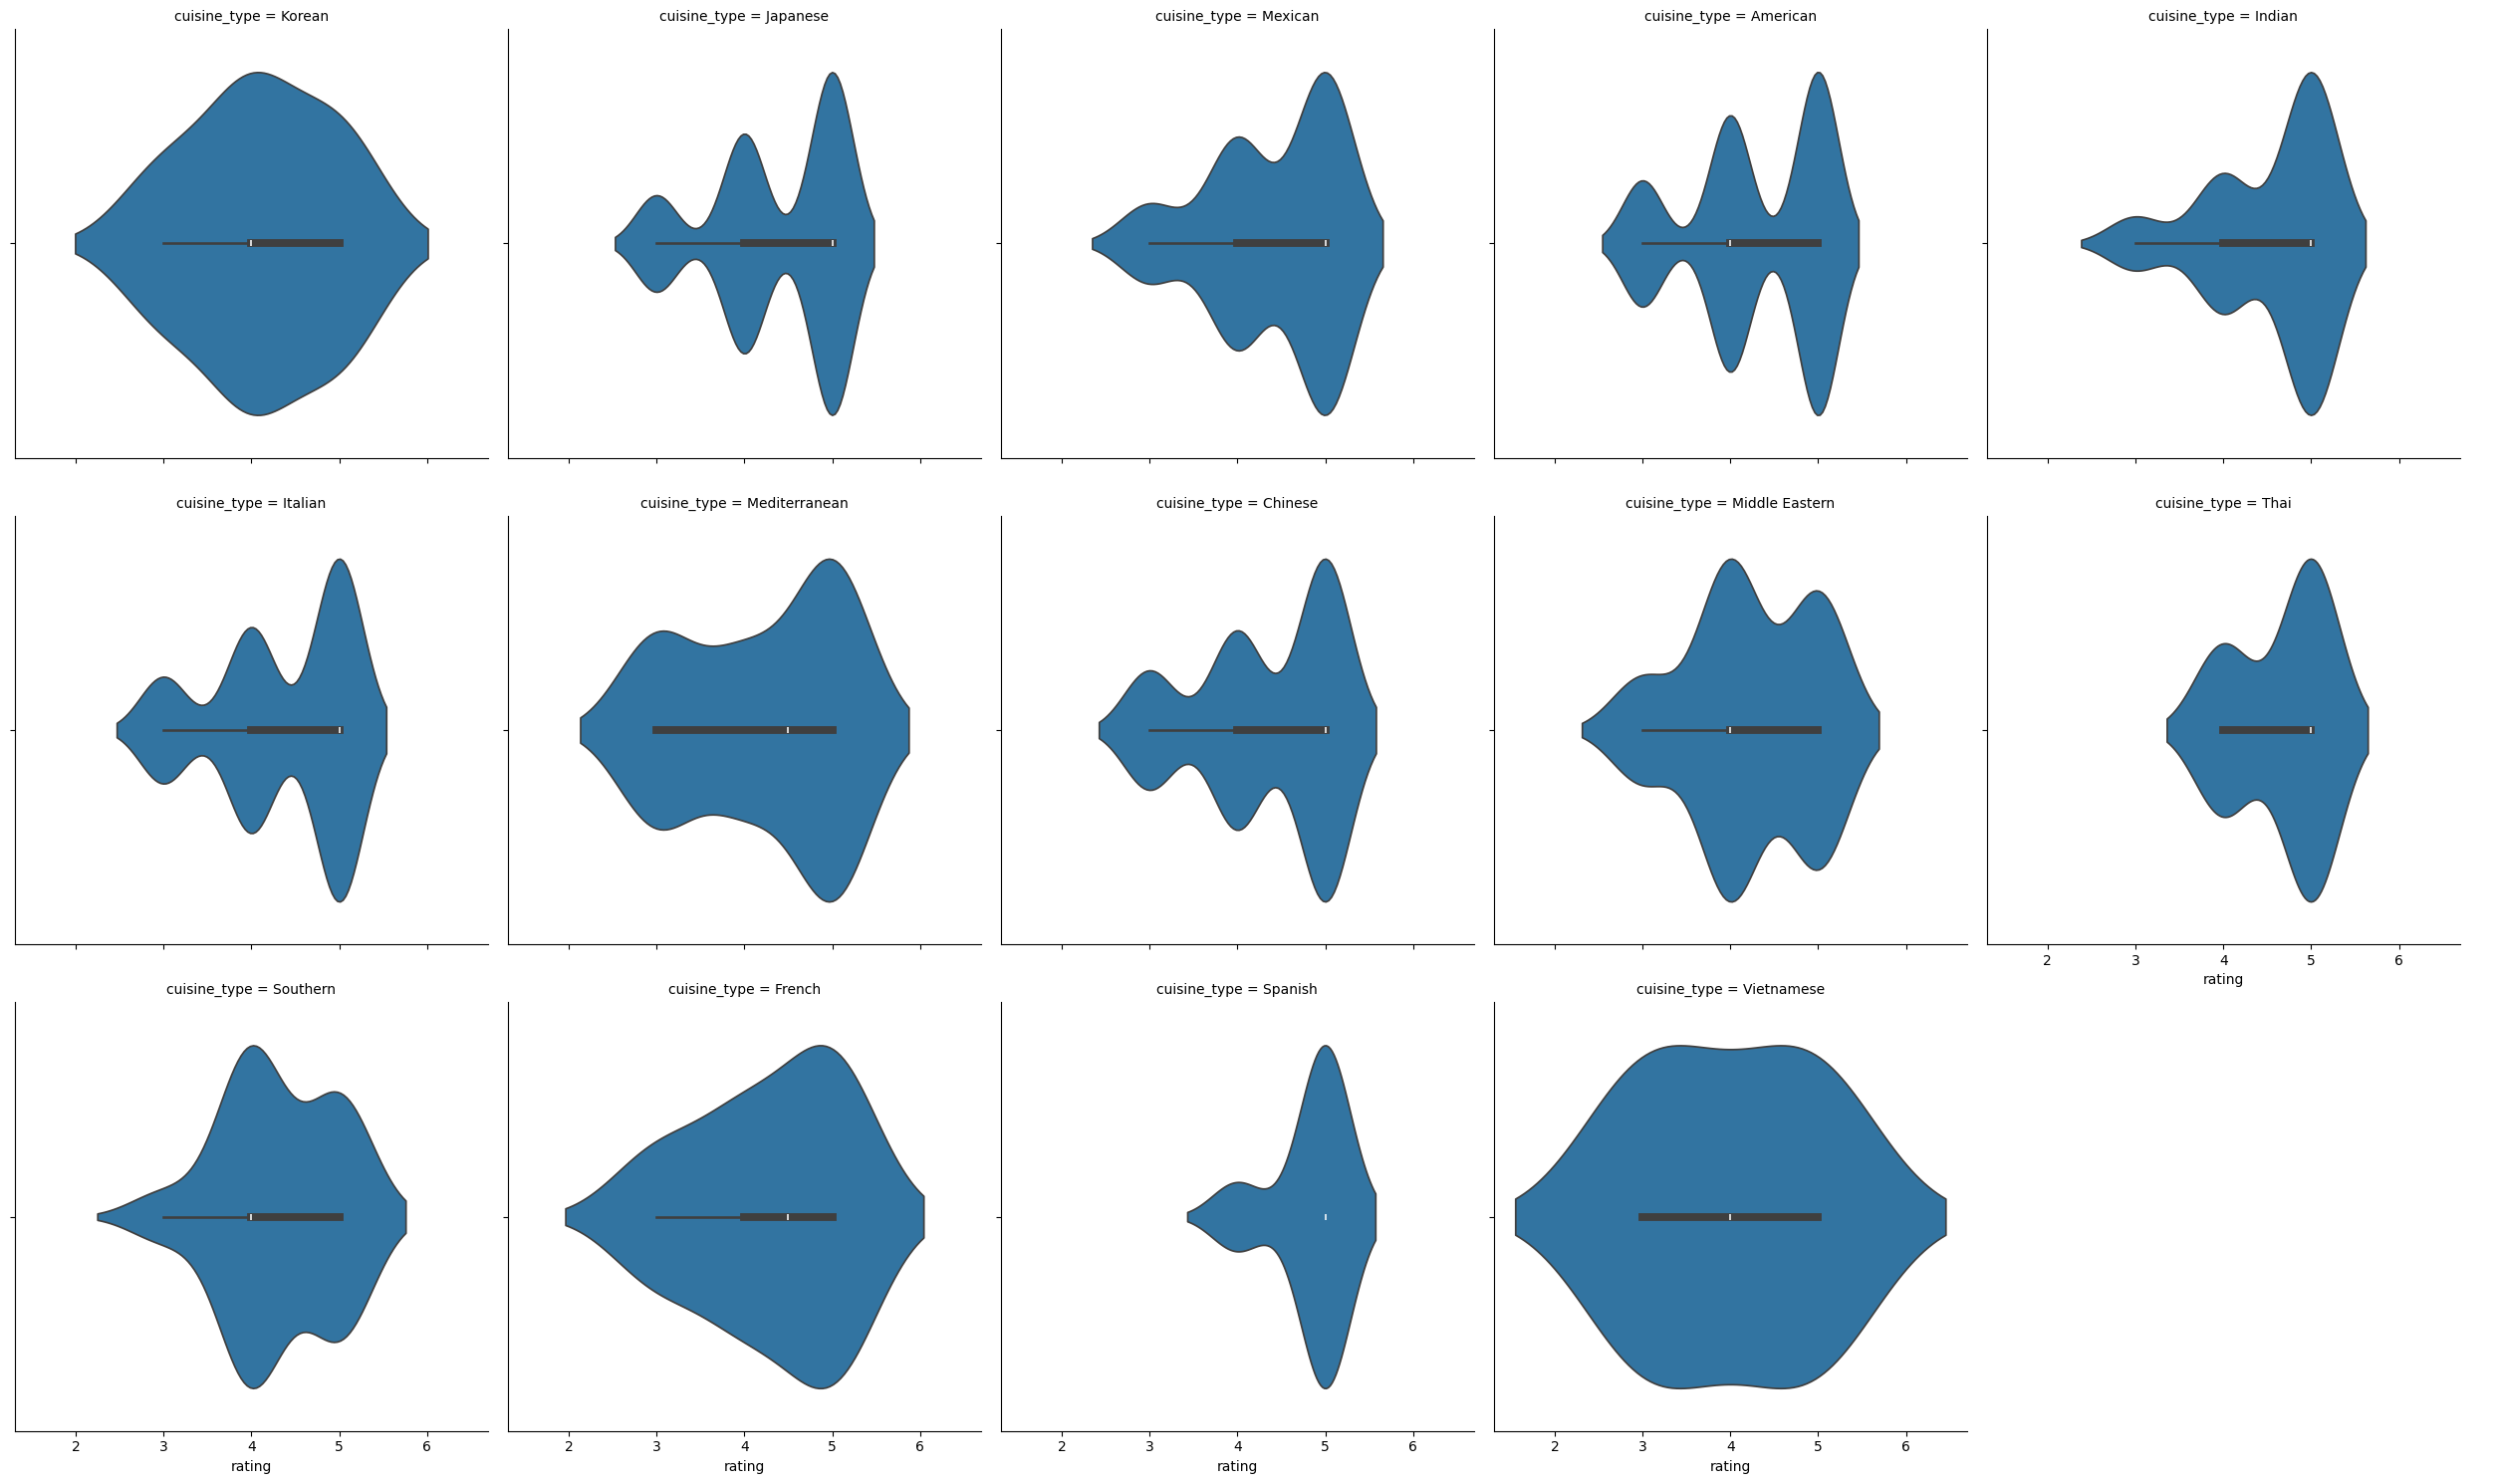

In [48]:
# cuisine types against ratings graph
sns.catplot(x='rating',
            col='cuisine_type',
            data=df,
            col_wrap=5,
            kind="violin")
plt.show()

* The average distribution of ratings for all cuisine types is medium average to high average which is 4 or 5 stars
* There are a few low ratings (3 stars) for all cuisine types

### **Cuisine Type x Cost of the Order**

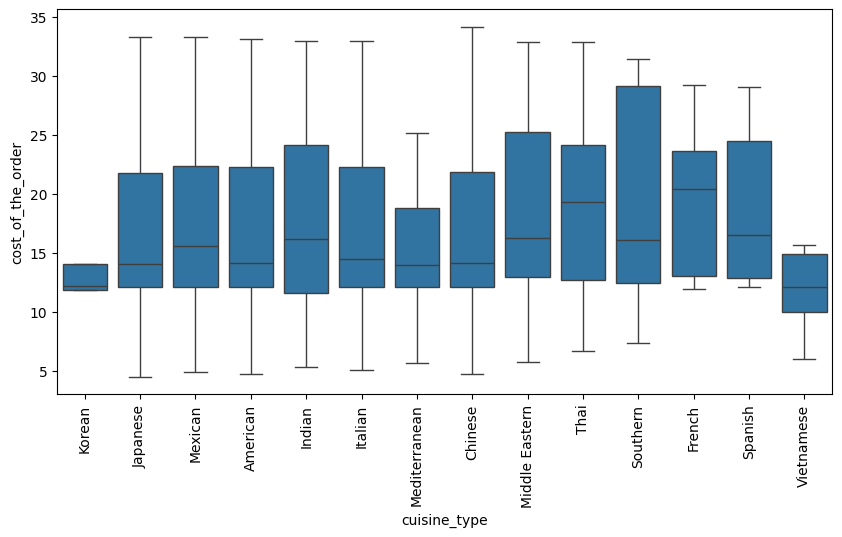

In [49]:
# cuisine type by cost of order graph

plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='cuisine_type',y='cost_of_the_order',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

* Southern food has a higher overal cost based on the quartile range
* The mean for most of the food types indicates that customers opt more for cheaper meals

### Cuisine Type x Food Preparation Time

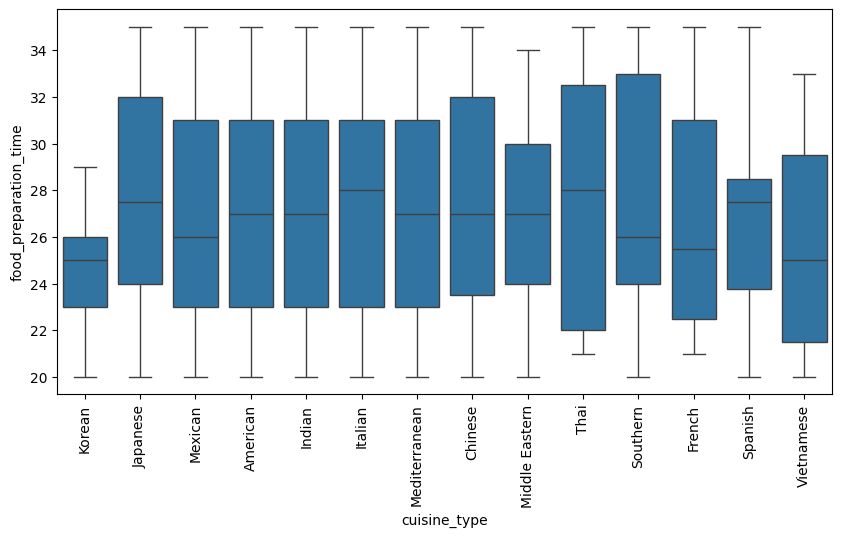

In [50]:
# cusine type by food preparation time graph

plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='cuisine_type',y='food_preparation_time',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

* On average Korean food takes the least amount of time to prepare
* Thai food takes the most amount of time to prepare
* The data is mostly uniform

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer

In [51]:
# calculating the mena and sum of ratings for all restaurants

rating_list_sum = df["rating"].groupby(df['restaurant_name']).sum().reset_index(
  name='Sum')

rating_list_mean = df["rating"].groupby(df['restaurant_name']).mean().reset_index(
  name='Mean')


In [52]:
# merging the mean and sum dataframes into 1 dataframe

rating_combined_mean_and_sum = pd.merge(rating_list_sum, rating_list_mean, how = "outer", on = "restaurant_name")

rating_combined_mean_and_sum.head()

,restaurant_name,Sum,Mean
0,'wichcraft,5.000,5.000
1,12 Chairs,9.000,4.500
2,5 Napkin Burger,8.000,4.000
3,67 Burger,5.000,5.000
4,Alidoro,0.000,NaN


In [53]:
# names of the restaurants that qualify for the promotion

rating_over_50_sum = rating_combined_mean_and_sum.loc[rating_combined_mean_and_sum['Sum'] > 50]

rating_over_50_sum_and_4_mean = rating_over_50_sum.loc[rating_over_50_sum['Mean'] > 4]

rating_over_50_sum_and_4_mean.reset_index( drop = True)

,restaurant_name,Sum,Mean
0,Bareburger,69.000,4.059
1,Blue Ribbon Fried Chicken,277.000,4.328
2,Blue Ribbon Sushi,308.000,4.219
3,Blue Ribbon Sushi Bar & Grill,101.000,4.591
4,Blue Ribbon Sushi Izakaya,78.000,4.333
5,Cafe Mogador,54.000,4.154
6,Chipotle Mexican Grill $1.99 Delivery,63.000,4.200
7,Five Guys Burgers and Fries,82.000,4.556
8,Han Dynasty,102.000,4.435
9,J. G. Melon,53.000,4.417


* There are 24 restaunrants that qualified for the promotion
* There are no restaurants with a perfect 5 rating
* The lowest total of ratings is 53 and the highest is 379 (The Meatball Shack)
* The lowest average is 4.059 (Bareburger) and the highest average rating is 4.591 Blue Ribbon Sushi Bar and Grill


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders

In [54]:
# locating the columns with the values we want to use

more_than_20_dollars = df.loc[df['cost_of_the_order'] > 20]
up_to_20_dollars = df.loc[df['cost_of_the_order'] <= 20]
up_to_5_dollars = df.loc[df['cost_of_the_order'] <= 5]

In [55]:
# sums of the values we want to use

sum_more_than_20_dollars = more_than_20_dollars['cost_of_the_order'].sum()
sum_up_to_20_dollars = up_to_20_dollars['cost_of_the_order'].sum()
sum_up_to_5_dollars = up_to_5_dollars['cost_of_the_order'].sum()


In [56]:
# revenue calculation

total_revenue = round((sum_more_than_20_dollars * 0.25) + ((sum_up_to_20_dollars - sum_up_to_5_dollars) * 0.15), 2)

print("The net revenue generated by the company accross all orders is", total_revenue, "dollars.")

The net revenue generated by the company accross all orders is 6166.3 dollars.


#### Observations:

* The compan made 6166 dollars and 30 cents through the application


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered)

In [57]:
# adding corresponding list items for food preparation time and delivery time then storing in a new list

time_from_order_to_delivery = []

for i in range(0, len(df['food_preparation_time'])):
  time_from_order_to_delivery.append(df['food_preparation_time'][i] + df['delivery_time'][i])

In [58]:
# storing values over 60 minites to a new list

orders_over_60_minutes = []

for i in range(0, len(time_from_order_to_delivery)):

 if time_from_order_to_delivery[i] > 60:
    orders_over_60_minutes.append(time_from_order_to_delivery[i])

In [59]:
# calculating and printing the percentage

print(round(len(orders_over_60_minutes) / len(time_from_order_to_delivery) * 100, 2),
      "% of orders take more than 60 minutes to get delivered from the time an order is placed")

10.54 % of orders take more than 60 minutes to get delivered from the time an order is placed


#### Observations:

* 10.54 percent of orders take over 1 hour from the time an order is place to delivery
* Majority of orders take 1 hour or less


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [60]:
# identifying weekends and weekdays asseperate data sets

weekday = df.loc[df['day_of_the_week'] == 'Weekday']

weekend = df.loc[df['day_of_the_week'] == 'Weekend']

In [61]:
# calculating the weekday and weekend averages as float values

weekday_mean = round(weekday['delivery_time'].sum() / len(weekday), 3)
weekend_mean = round(weekend['delivery_time'].sum() / len(weekend), 3)

print ("weekday mean =", weekday_mean, "and weekend mean =", weekend_mean)

weekday mean = 28.34 and weekend mean = 22.47


In [62]:
# converting averages to time

print("The weekday mean delivery time is", int(weekday_mean), "minutes and", int(0.34 * 60), "seconds.")
print("The weekend mean delivery time is", int(weekend_mean), "minutes and", int(0.47 * 60), "seconds.")

The weekday mean delivery time is 28 minutes and 20 seconds.
The weekend mean delivery time is 22 minutes and 28 seconds.


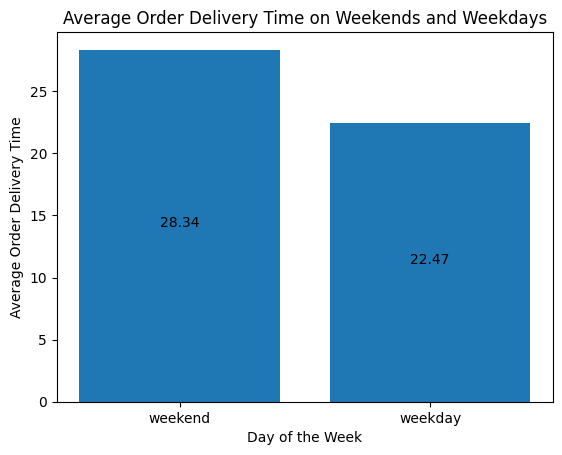

In [63]:
# plotting graph

mean_time_x_day = {"weekend": weekday_mean, "weekday": weekend_mean}

day_names = list(mean_time_x_day.keys())
day_values = list(mean_time_x_day.values())

yt = plt.bar(range(len(day_names)), day_values, tick_label= day_names)

 # adding value labels on top of each bar
plt.bar_label(yt, labels = day_values, label_type = "center", padding = 2,)

 # giving title to the plot
plt.title("Average Order Delivery Time on Weekends and Weekdays")

 # giving X and Y labels
plt.xlabel("Day of the Week")
plt.ylabel("Average Order Delivery Time")

plt.show()


#### Observations:

* On weekends it takes an average of 28 minutes and 20 seconds to deliver an order
* On weekdays it takes an average of 22 minues and 28 seconds to deliver an order
* It takes longer to deliver orders on weekends than on week days because there are more orders on weekends


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations)

### Conclusions:

**Rating**

*  The ratings from customers on the application have mostly been positive
* There are no overly negetive ratings from customers on the application, the lowest ratings are 3 stars, which is at the very least positive
* This shows that the restaurants on these lists are average to very good

* There isn't a strong correlation between rating and any other category, delivery time and order preparation time have posive correlation with rating but it is a weak one
* This means that quality and taste of the food might be affecting ratings more than time taken to make and deliver food

**Cost of Food**
* The cost of order seems to be a factor to be considered as most customers opt for cheaper meals shown by the right skewedness of the data

**Cuisine Type**
* There are 4 cuisine types that are most popular among customers namely American, Japanese, Mediterranean and Chinese
* The most popular restaurants fall within these 4 cusine types
* Most orders, more than 50 percent came from these 4 cusine types out of the 14 types to choose from
* This might be because customers are accustomed to these cusine types and do not want to order unfamiliar cuisine types

* These cuisine types are most popular on the weekends as their total order double during that time of the week
* Order quantities seem to be lower on weekdays which have a 5 day period compared to weekends which only have a 2 day period
* This may be due to customers buying food on their way home or not wanting to wait a long time for orders after a long day of work

### Recommendations:

* The goal of this analysis was to figure out what is affecting customer satisfaction so that these issues may be solved to drive up business and return customers on the application

**Rating**
* Customers with a lower satisfaction score represented by rating tend to order once on the application
* The business should follow up these customer reviews so as to get more qualitative data on why the customer had low satisfaction
* The business can also offer promotions in terms of discounts or coupons to turn around the perspective of these customers to be more positive towards the business, this will also help to get them back as retirn customers
* The business should send out personalised adverts and promotions to customers who ordered once or twice to get them back as repeat customers
* The business can set up a rewards system for all customers as an incentive for thier loyalty
* The business should create a reward or bonus for customers who recommend the application to others, setting this up through a unique recommendation link, something like a free meal or free delivery or discounts for customers who reach a certain number of recommedations
* This will increase the number of new customers on the application



**Cusine Type**

* The top cuisines are mostly popular on weekends, the business should run weekend promos for customers to order these types of cuisines, this will also bring in new customers as the popularity of these cusines is also a reflection of the population
* The business should run personalised adverts and promotions for current customer base based on their prefered cuisine types.
* The business should recommend the higher performing restaurants to customers who had a lower satisfaction score with the restaurant they chose on their previous orders
* The business should get demographic data to see if there is a correlation betweeen cusine type and matrics such as age gender, income level and ethnicity, and then tailor recommendations and adverts to a greater population based on the results
* The business should recommend the lower perfoming cuisine types in terms of customer numbers, but only if they have a high average customer rating. This will lure new and old customers to try new things and increase order numbers

---